# Quantum Machine Learning for Credit Card Fraud Detection

##### Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_aer.primitives import Sampler

# Set random seed for reproducibility
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


##### Load and Balance Data

In [14]:
# Load the dataset
df = pd.read_csv('data/creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['Class'].value_counts()}")

Dataset shape: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [15]:
# Balance the dataset via undersampling
# Match the number of valid transactions to fraud cases
fraud = df[df['Class'] == 1]
valid = df[df['Class'] == 0].sample(n=len(fraud), random_state=42)
balanced_df = pd.concat([fraud, valid]).sample(frac=1, random_state=42)

print(f"Balanced dataset shape: {balanced_df.shape}")
print(f"Class distribution after balancing:\n{balanced_df['Class'].value_counts()}")

Balanced dataset shape: (984, 31)
Class distribution after balancing:
Class
0    492
1    492
Name: count, dtype: int64


In [16]:
# Subset to 400 samples (larger than before for more reliable metrics)
# Keep it manageable for the quantum simulator
subset_df = balanced_df.sample(n=400, random_state=42)

X = subset_df.drop('Class', axis=1)
y = subset_df['Class']

print(f"Subset shape: {X.shape}")
print(f"Class distribution in subset:\n{y.value_counts()}")

Subset shape: (400, 30)
Class distribution in subset:
Class
1    208
0    192
Name: count, dtype: int64


##### Train/Test Split FIRST (Preventing Data Leakage)



In [17]:
# FIX 1: Split BEFORE preprocessing
# FIX 2: stratify=y ensures both splits have equal fraud/non-fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # FIX: ensures class balance in both train and test
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training set: (320, 30)
Test set:     (80, 30)

Train class distribution:
Class
1    166
0    154
Name: count, dtype: int64

Test class distribution:
Class
1    42
0    38
Name: count, dtype: int64


##### Standardize (fit on train only)

In [18]:
# FIX: fit_transform on train, transform only on test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learns mean/std from train only
X_test_scaled  = scaler.transform(X_test)       # applies same transform to test

print("Scaling complete.")

Scaling complete.


##### PCA - fit on train only, check variance explained

In [19]:
# FIX: fit PCA on train only, then transform both
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_scaled)  # learns components from train only
X_test_pca  = pca.transform(X_test_scaled)       # applies same transform to test

# FIX: Always check how much information is retained
variance_explained = pca.explained_variance_ratio_.sum()
print(f"Variance explained by 4 components: {variance_explained:.2%}")
print("\nVariance per component:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.2%}")

if variance_explained < 0.85:
    print("\n⚠️  Warning: Less than 85% of variance retained.")
    print("   The QSVM may underperform partly due to information loss in PCA.")
else:
    print("\n✅ Good: Sufficient variance retained.")

Variance explained by 4 components: 61.56%

Variance per component:
  PC1: 39.42%
  PC2: 10.01%
  PC3: 6.41%
  PC4: 5.73%

⚠️  Warning: Less than 85% of variance retained.
   The QSVM may underperform partly due to information loss in PCA.


##### Train Classical SVM (Tuned Baseline)

In [20]:
# Tune the classical SVM with GridSearchCV for a fair comparison
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_pca, y_train)

print(f"Best classical SVM params: {grid_search.best_params_}")
classical_svc = grid_search.best_estimator_

# Predict and evaluate
c_predictions = classical_svc.predict(X_test_pca)

print("\nClassical SVM Classification Report:")
print(classification_report(y_test, c_predictions))

Best classical SVM params: {'C': 1, 'gamma': 'auto'}

Classical SVM Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.90        38
           1       1.00      0.81      0.89        42

    accuracy                           0.90        80
   macro avg       0.91      0.90      0.90        80
weighted avg       0.92      0.90      0.90        80



##### Set Up Quantum Kernel

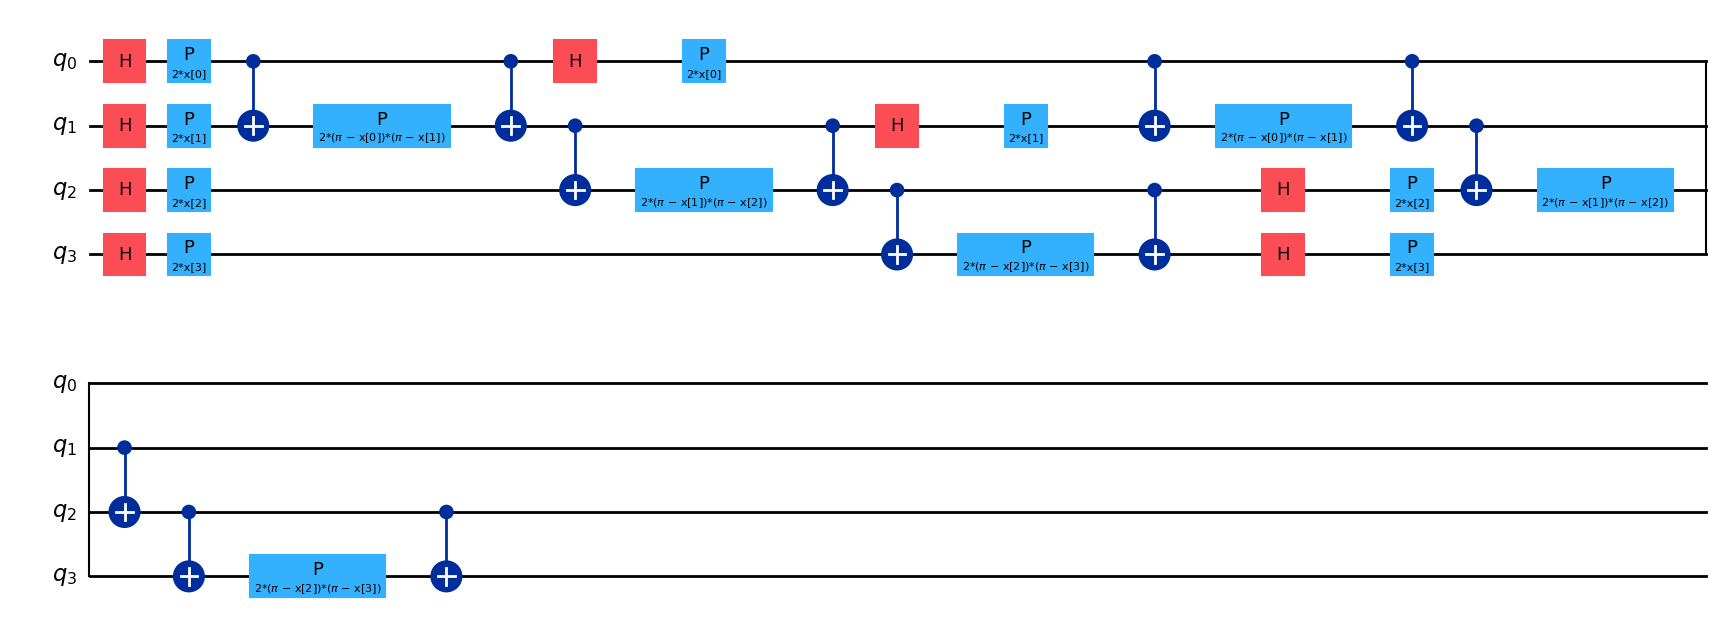

Quantum Kernel mapped successfully!


In [21]:
# Number of features = number of qubits
num_features = X_train_pca.shape[1]

# Define Quantum Feature Map
feature_map = ZZFeatureMap(feature_dimension=num_features, reps=2, entanglement='linear')

# Plot the circuit
display(feature_map.decompose().draw(output='mpl'))

# Set up the Sampler (Aer simulator)
sampler = Sampler()

# Create the Quantum Kernel
qkernel = FidelityQuantumKernel(feature_map=feature_map)

print("Quantum Kernel mapped successfully!")

##### Train and Evaluate Quantum SVM

In [22]:
# Train QSVM using the Quantum Kernel
qsvm = SVC(kernel=qkernel.evaluate)
qsvm.fit(X_train_pca, y_train)

# Predict and evaluate
q_predictions = qsvm.predict(X_test_pca)

print("Quantum SVM Classification Report:")
print(classification_report(y_test, q_predictions))

Quantum SVM Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.45      0.50        38
           1       0.58      0.69      0.63        42

    accuracy                           0.57        80
   macro avg       0.57      0.57      0.57        80
weighted avg       0.57      0.57      0.57        80



##### Visualize Confusion Matrices

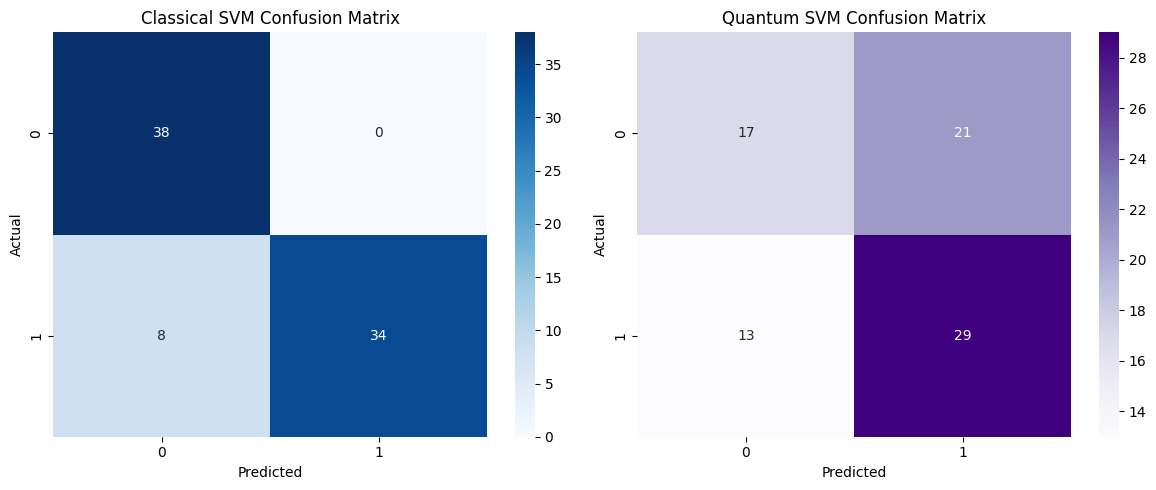

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Classical Confusion Matrix
cm_classical = confusion_matrix(y_test, c_predictions)
sns.heatmap(cm_classical, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Classical SVM Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Quantum Confusion Matrix
cm_quantum = confusion_matrix(y_test, q_predictions)
sns.heatmap(cm_quantum, annot=True, fmt='d', cmap='Purples', ax=ax[1])
ax[1].set_title('Quantum SVM Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

##### Summary Comparison

In [24]:
from sklearn.metrics import accuracy_score, f1_score

c_acc = accuracy_score(y_test, c_predictions)
q_acc = accuracy_score(y_test, q_predictions)
c_f1  = f1_score(y_test, c_predictions)
q_f1  = f1_score(y_test, q_predictions)

print("Model Comparison Summary")
print("-" * 40)
print(f"{'Model':<20} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 40)
print(f"{'Classical SVM':<20} {c_acc:>10.2%} {c_f1:>10.4f}")
print(f"{'Quantum SVM':<20} {q_acc:>10.2%} {q_f1:>10.4f}")
print("-" * 40)
print(f"\nPCA variance retained: {variance_explained:.2%}")
print(f"Test set size: {len(y_test)} samples")

Model Comparison Summary
----------------------------------------
Model                  Accuracy   F1 Score
----------------------------------------
Classical SVM            90.00%     0.8947
Quantum SVM              57.50%     0.6304
----------------------------------------

PCA variance retained: 61.56%
Test set size: 80 samples
